# Lead-Lag Detection

*Notebook version with dashboard figures inserted in the relevant analytical sections.*

## 0.moduls import

In [1]:
%load_ext autoreload
%autoreload 2

from strategy import *

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.unicode_minus']=False

## 1. Summary & Data
本项目开发的策略关注美国房地产和家具供应链中各11家公司，以yahoo finance的每日股票数据为基础尝试提出更好的持仓策略以期望得到更高收益。  

主要采用的方法是：  
以**K-means cluster**分割市场讯息，找出牛市/熊市的不同状态，为后续寻找不同滞后期做准备。  
**Lévy Area**用于识别系统性的leader和follower。  
**Granger Causality Test**测量信息传导所需的滞后期。  
  
策略验证为取新两个月的股价数据，以我们制定的策略进行交易，与平均持仓的收益率对比。

In [3]:
returns_df = load_and_preprocess_data(base_path=".")
aligned_benchmark = fetch_aligned_benchmark(returns_df, ticker='SPY')

print(f"Universe Shape: {returns_df.shape[0]} trading days, {returns_df.shape[1]} assets.")
display(returns_df.tail(3))

Universe Shape: 2238 trading days, 24 assets.


,ETH_history,FND_history,HD_history,LEG_history,LOW_history,LZB_history,MHK_history,MLKN_history,RH_history,SHW_history,...,EQIX_history,KBH_history,LEN_history,NVR_history,PHM_history,PLD_history,PSA_history,SPG_history,TOL_history,WELL_history
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-25 05:00:00+00:00,0.117747,-0.015802,-0.023174,-0.009524,-0.055889,0.018141,-0.018832,-0.016517,-0.033561,-0.020508,...,0.014555,-0.027602,-0.048711,-0.029534,-0.044642,-0.001925,-0.015652,0.008075,-0.015787,-0.001486
2026-02-26 05:00:00+00:00,-0.024427,0.023792,-0.001278,0.034091,0.005209,0.015869,0.010204,-0.000480,0.014130,0.009097,...,-0.013014,0.006502,0.011469,0.020733,0.007800,0.018782,0.015367,0.008010,0.009802,0.000960
2026-02-27 05:00:00+00:00,-0.050600,-0.014970,0.015010,-0.012680,0.000681,-0.021102,0.004249,-0.024319,-0.111998,0.005797,...,0.027679,0.001733,0.021071,0.011252,0.011352,-0.000631,0.010232,0.006170,-0.008887,-0.006380


### 图一：Furniture 历史价格、交易量与波动率趋势

该图放在 **Summary & Data** 后面，作为样本期量价与波动率特征的入口。下方散点图已加入 OLS 趋势线，使交易量与波动率的正相关关系（ρ≈0.63）更直观。

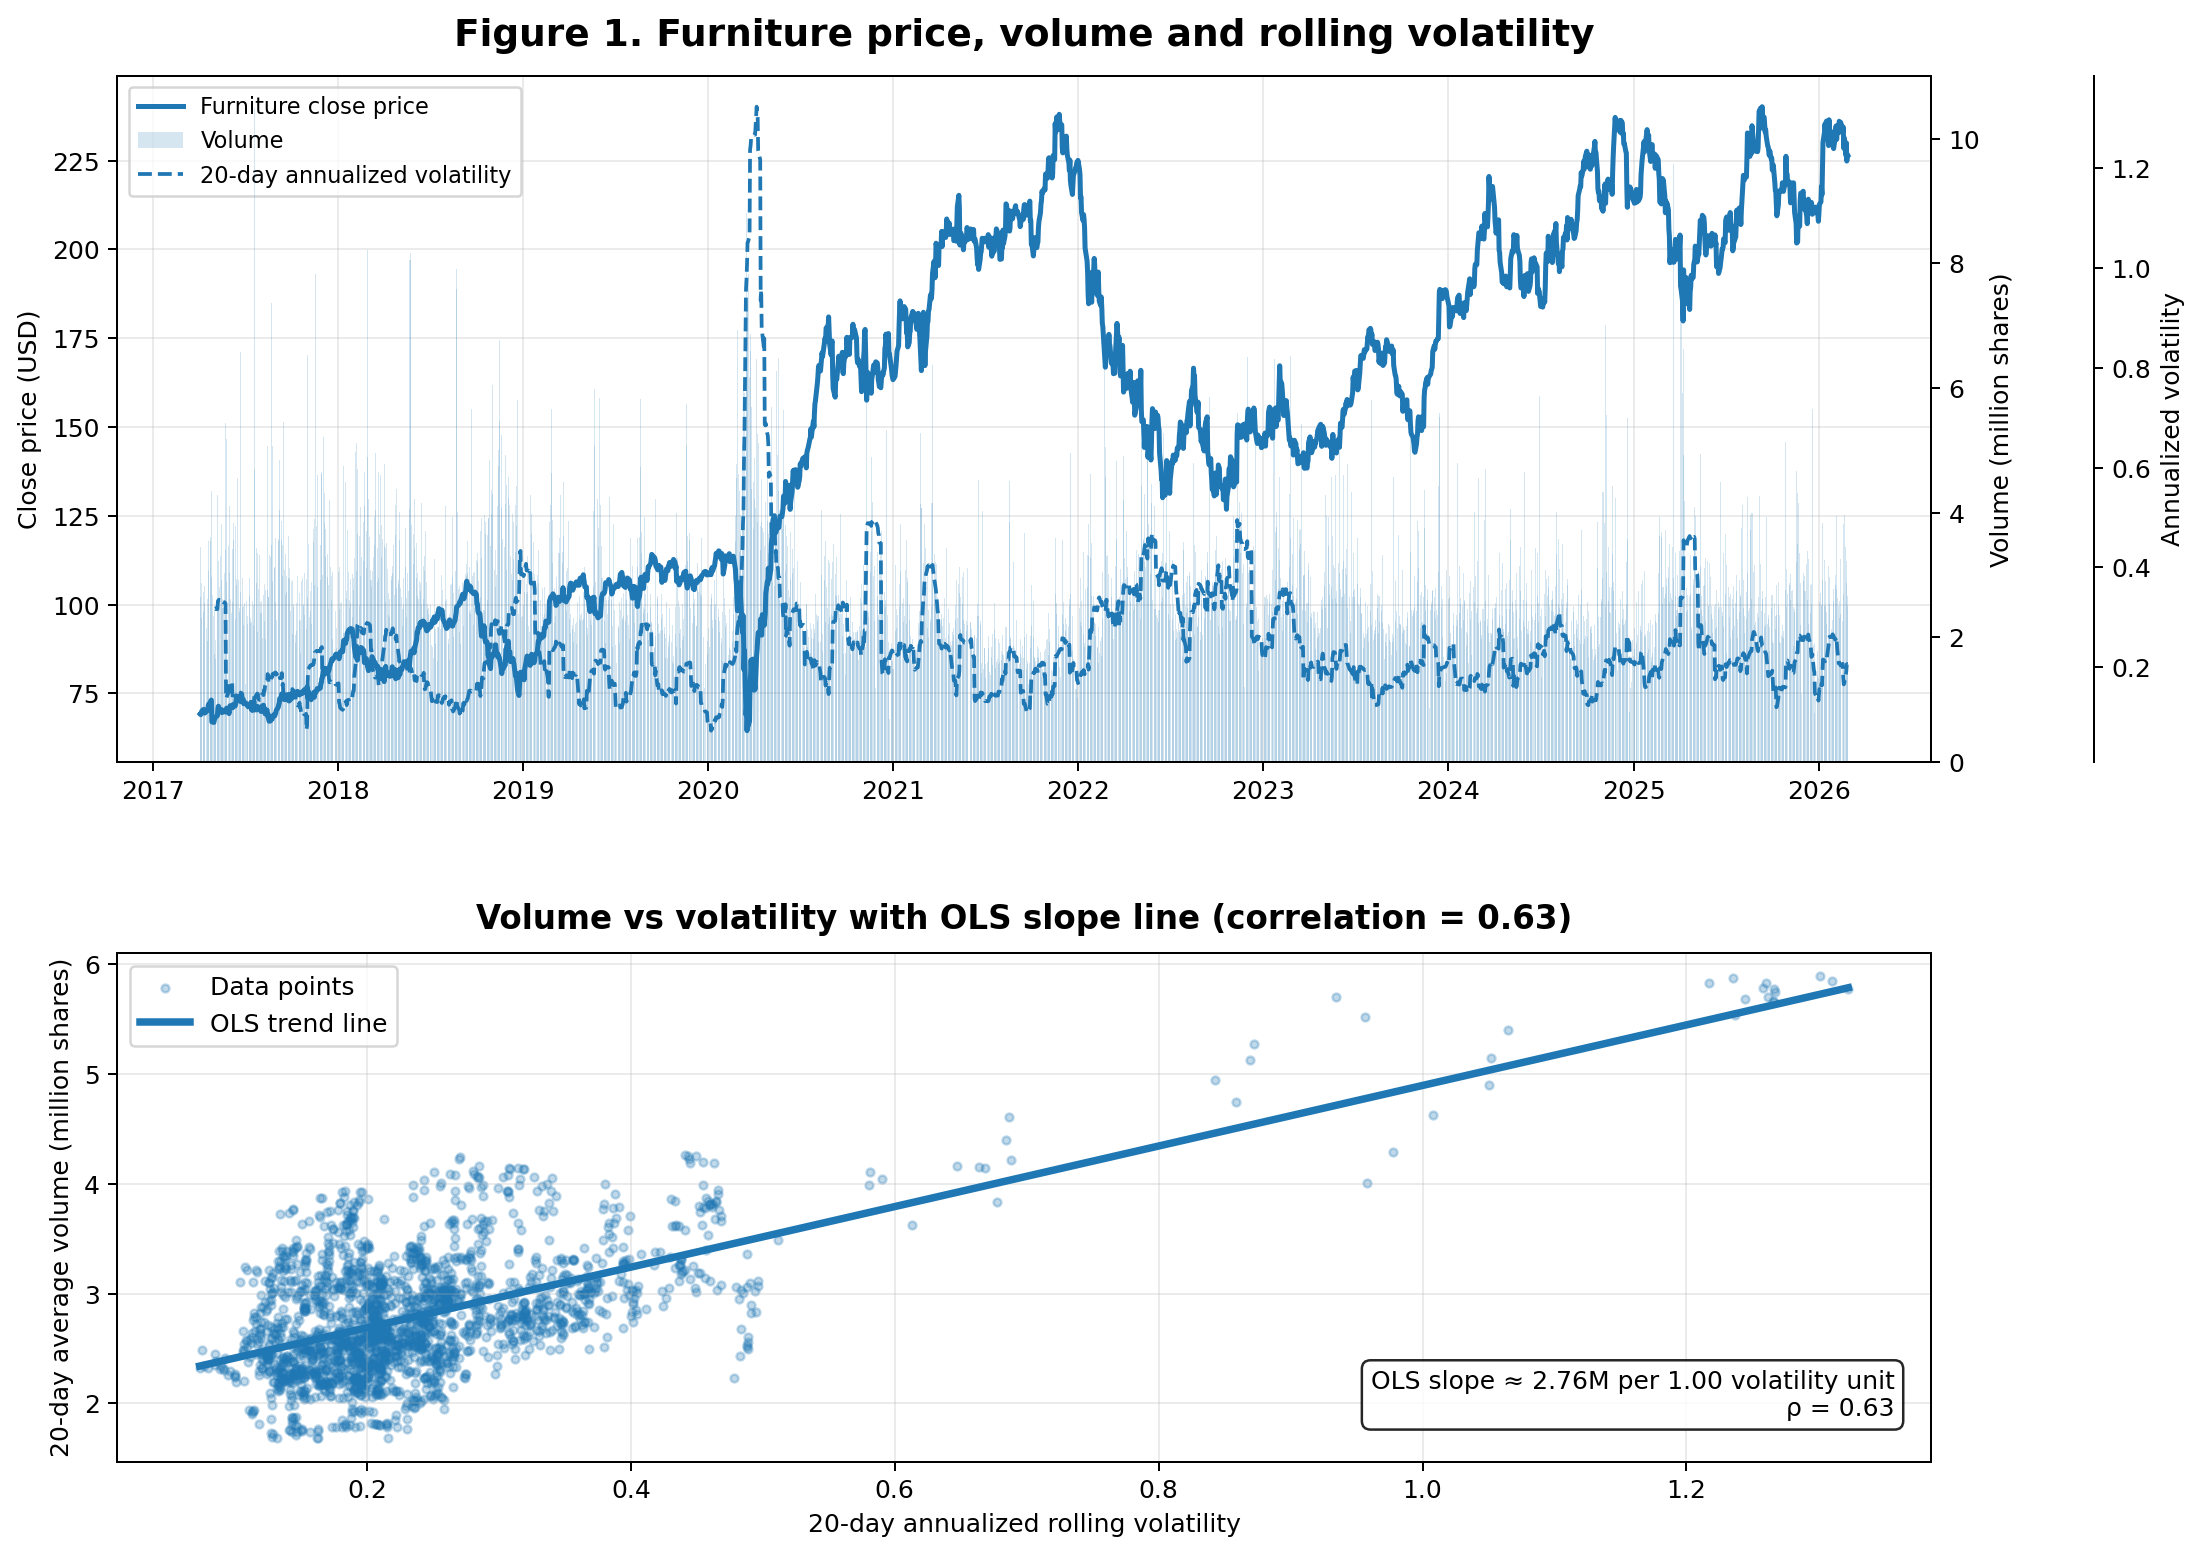

### 图二：House 日收益率分布与 Q-Q Plot 肥尾检验

该图继续放在 **Summary & Data** 后面，用来说明收益率并非正态分布，存在尖峰肥尾，因此后续采用状态切分与非线性结构分析有必要性。

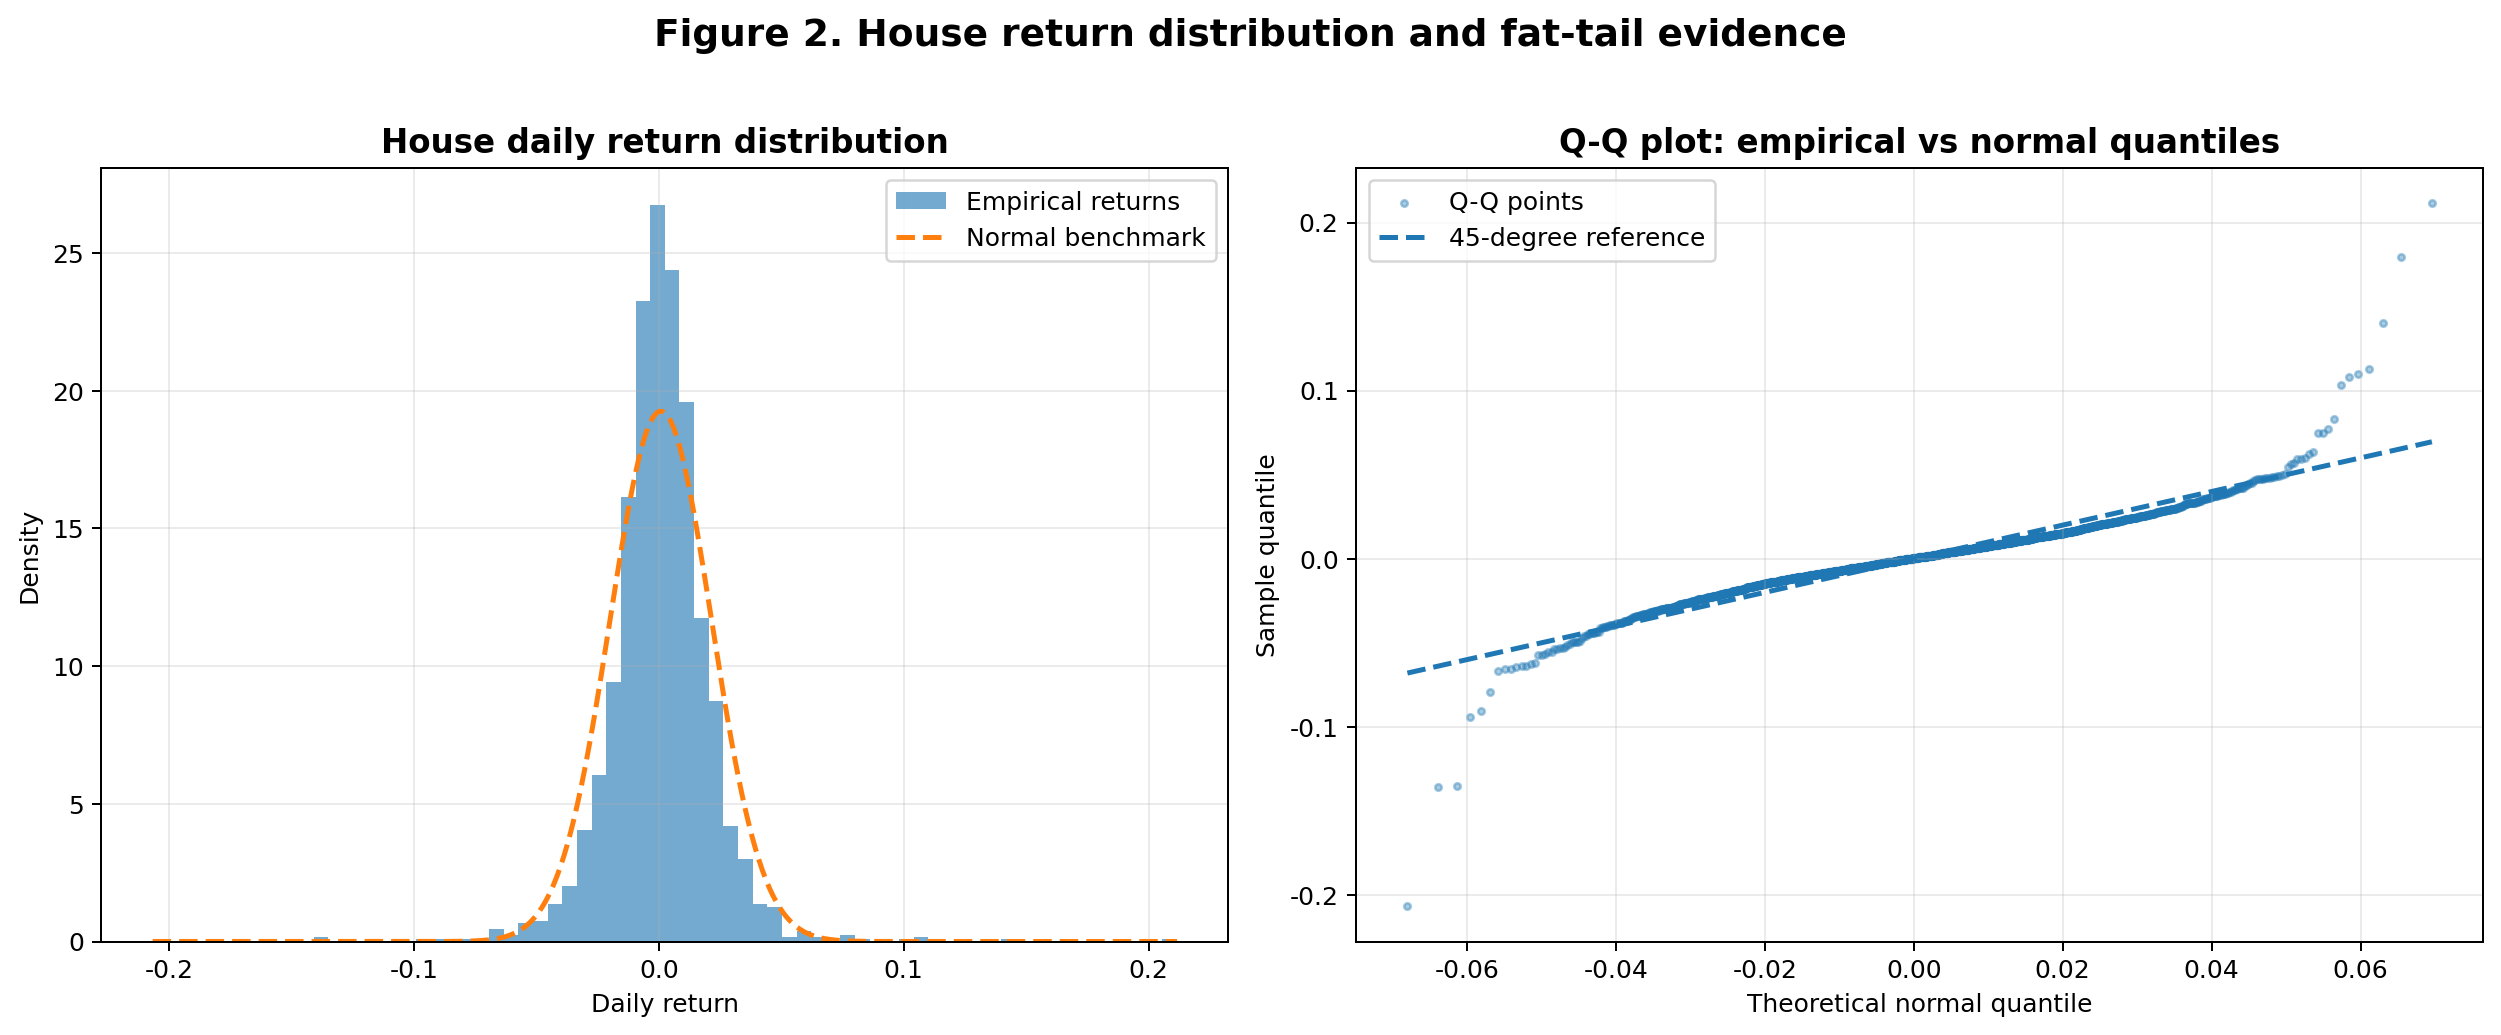

## 2. Methodology Module I: K-Means
在量化模型中，识别市场所处的"状态"至关重要。  
根据一般经验，市场在划分为"牛市"/"熊市"的区别会更加贴近于认知，所以聚类类别尝试为2类。  


关于是否要**引入外生特征聚类**的问题，我们设计了一组对比实验。
*   **测试 A（宏观驱动）**：引入 CBOE 波动率指数 (VIX) 作为特征进行聚类。
*   **测试 B（内生微观）**：仅使用股票池内部的**Cross-sectional Volatility, $CSVol_t$** 和
  **Short-term Momentum, $Mom_t$**。  

**结论**：实证发现，引入 VIX 会带来过多的外部宏观噪音，导致聚类结果不够纯粹。相反，完全剥离 VIX 后，仅凭板块内部微观特征跑出的 K-Means 聚类，能够极其敏锐且干净地将市场切分为"平稳期"与"高波动的尾部风险期"。因此，我们最终**放弃了 VIX，采用纯微观内生模型**。

### VIX Validation as Post-hoc Label（事后验证）
虽然我们不将 VIX 作为 K-Means 的直接输入特征，但我们用 VIX 作为事后的 **Label** 来验证内生聚类模型是否具有宏观经济学意义。  
具体做法：用 VIX > 20 作为 **Threshold** 定义宏观高波动期，检查该定义与 K-Means 切分出的高波动状态的重叠率。  
若两者高度吻合，说明我们的纯内生模型具有真实的经济学意义，而非过拟合噪音。


【测试 A】包含 VIX 噪音的聚类结果：


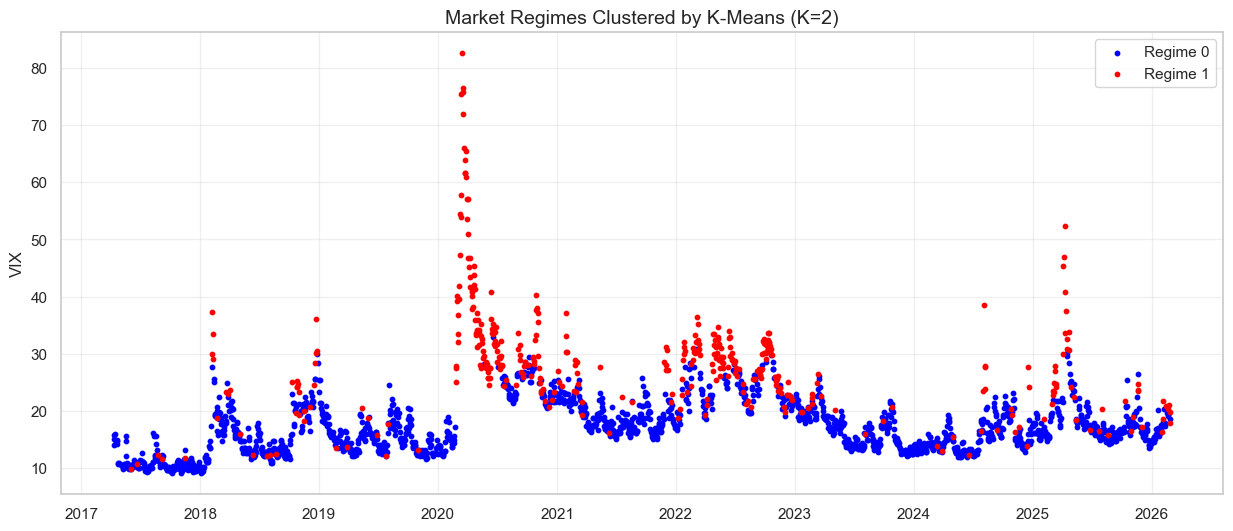

【测试 B】纯内生微观特征聚类结果（剥离外部噪音，更清晰）：


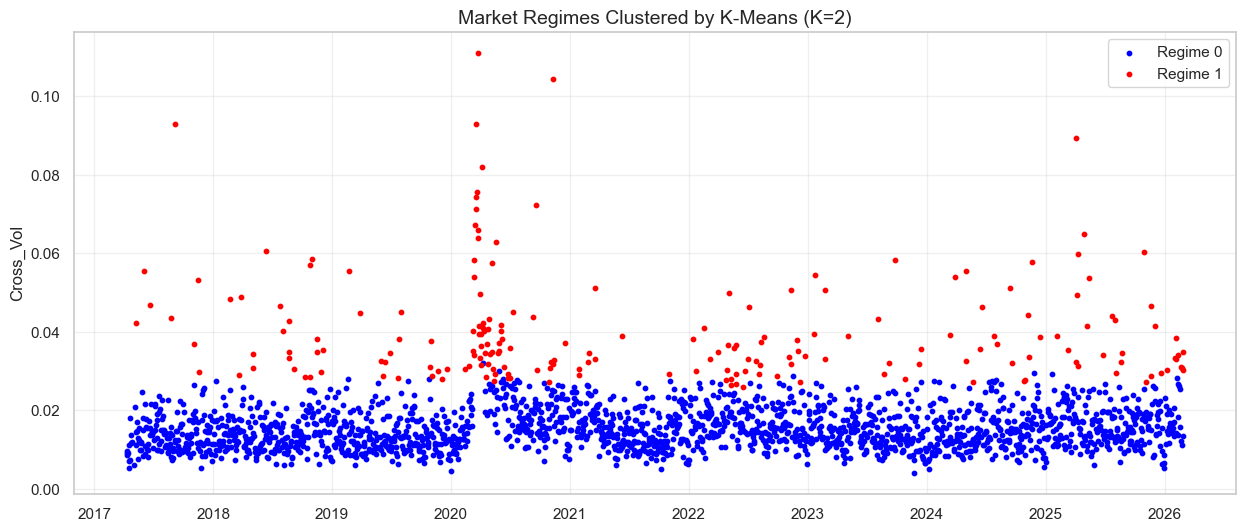

In [4]:
vix_df = fetch_vix_data(returns_df)

#exodogenous
features_macro = prepare_clustering_features(returns_df, vix_df=vix_df, use_vix=True)
clustered_macro, _, _ = run_regime_clustering(features_macro, n_clusters=2)

print("【测试 A】包含 VIX 噪音的聚类结果：")
plot_regimes(clustered_macro, target_feature='VIX', n_clusters=2)

#indogenous
features_micro = prepare_clustering_features(returns_df, use_vix=False)
clustered_micro, model_final, scaler_final = run_regime_clustering(features_micro, n_clusters=2)

print("【测试 B】纯内生微观特征聚类结果（剥离外部噪音，更清晰）：")
plot_regimes(clustered_micro, target_feature='Cross_Vol', n_clusters=2)

K-Means High-Vol Regime vs. VIX>20 Overlap Rate: 68.2%
（高于 50% 说明内生模型与宏观信号吻合，具有经济学意义）


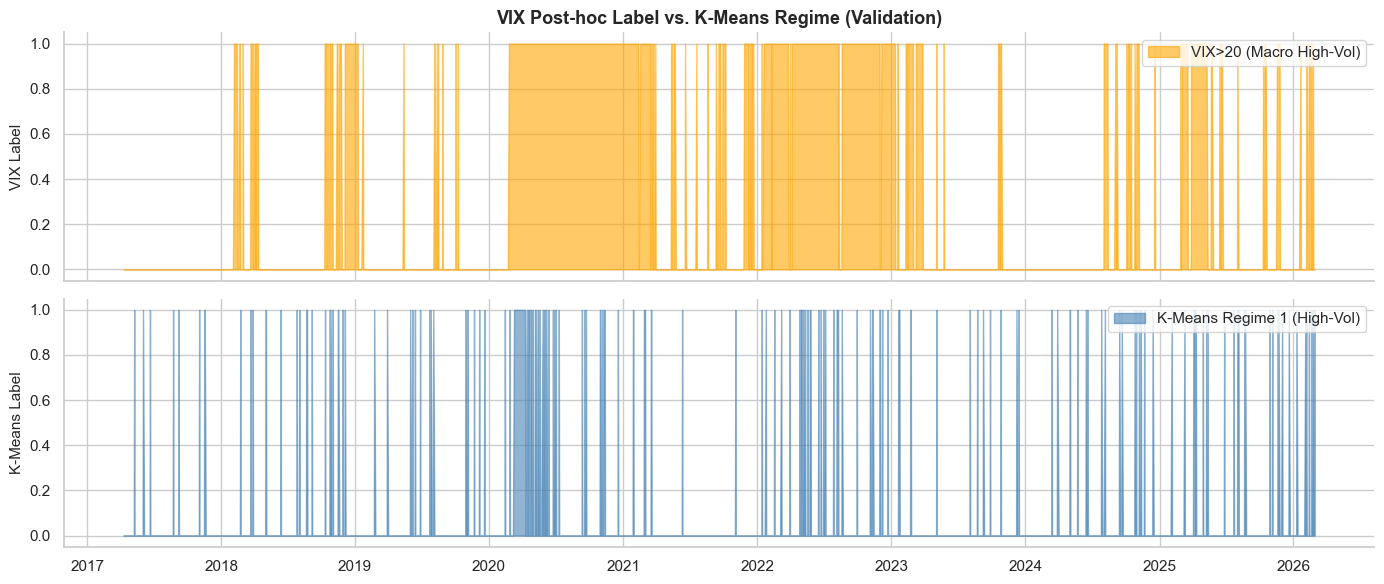

In [5]:
# === VIX Validation as Post-hoc Label ===
# 用 VIX > 20 作为宏观阈值定义高波动期，验证内生 K-Means 模型的经济学意义
# 注意：VIX 不参与聚类，仅作为事后验证标签

vix_validate = vix_df.reindex(clustered_micro.index).dropna()
labels_aligned = clustered_micro.reindex(vix_validate.index)

# 确定哪个 Regime 是高波动状态（Cross_Vol 均值更高的那个）
micro_features_aligned = features_micro.reindex(vix_validate.index)
regime_vol = micro_features_aligned.groupby(labels_aligned['Regime'])['Cross_Vol'].mean()
high_vol_regime = regime_vol.idxmax()

# VIX > 20 作为宏观高波动 label
vix_high = (vix_validate['VIX'] > 20).astype(int)
kmeans_high = (labels_aligned['Regime'] == high_vol_regime).astype(int)

# 计算重叠率（Overlap Rate）
overlap = (vix_high == kmeans_high).mean()
print(f"K-Means High-Vol Regime vs. VIX>20 Overlap Rate: {overlap*100:.1f}%")
print(f"（高于 50% 说明内生模型与宏观信号吻合，具有经济学意义）")

# 可视化对比
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].fill_between(vix_validate.index, 0, vix_high.values,
                     color='orange', alpha=0.6, label='VIX>20 (Macro High-Vol)')
axes[0].set_ylabel('VIX Label', fontsize=11)
axes[0].legend(loc='upper right')
axes[0].set_title('VIX Post-hoc Label vs. K-Means Regime (Validation)', fontsize=13, fontweight='bold')

axes[1].fill_between(labels_aligned.index, 0, kmeans_high.values,
                     color='steelblue', alpha=0.6, label=f'K-Means Regime {high_vol_regime} (High-Vol)')
axes[1].set_ylabel('K-Means Label', fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
sns.despine()
plt.show()


### 图四：两板块滚动波动率与市场状态共振

该图放在 **K-Means** 之后，用来连接聚类结果与市场状态解释：两板块波动率在危机期同步上升，支持用波动率与动量特征做 Regime 切分。

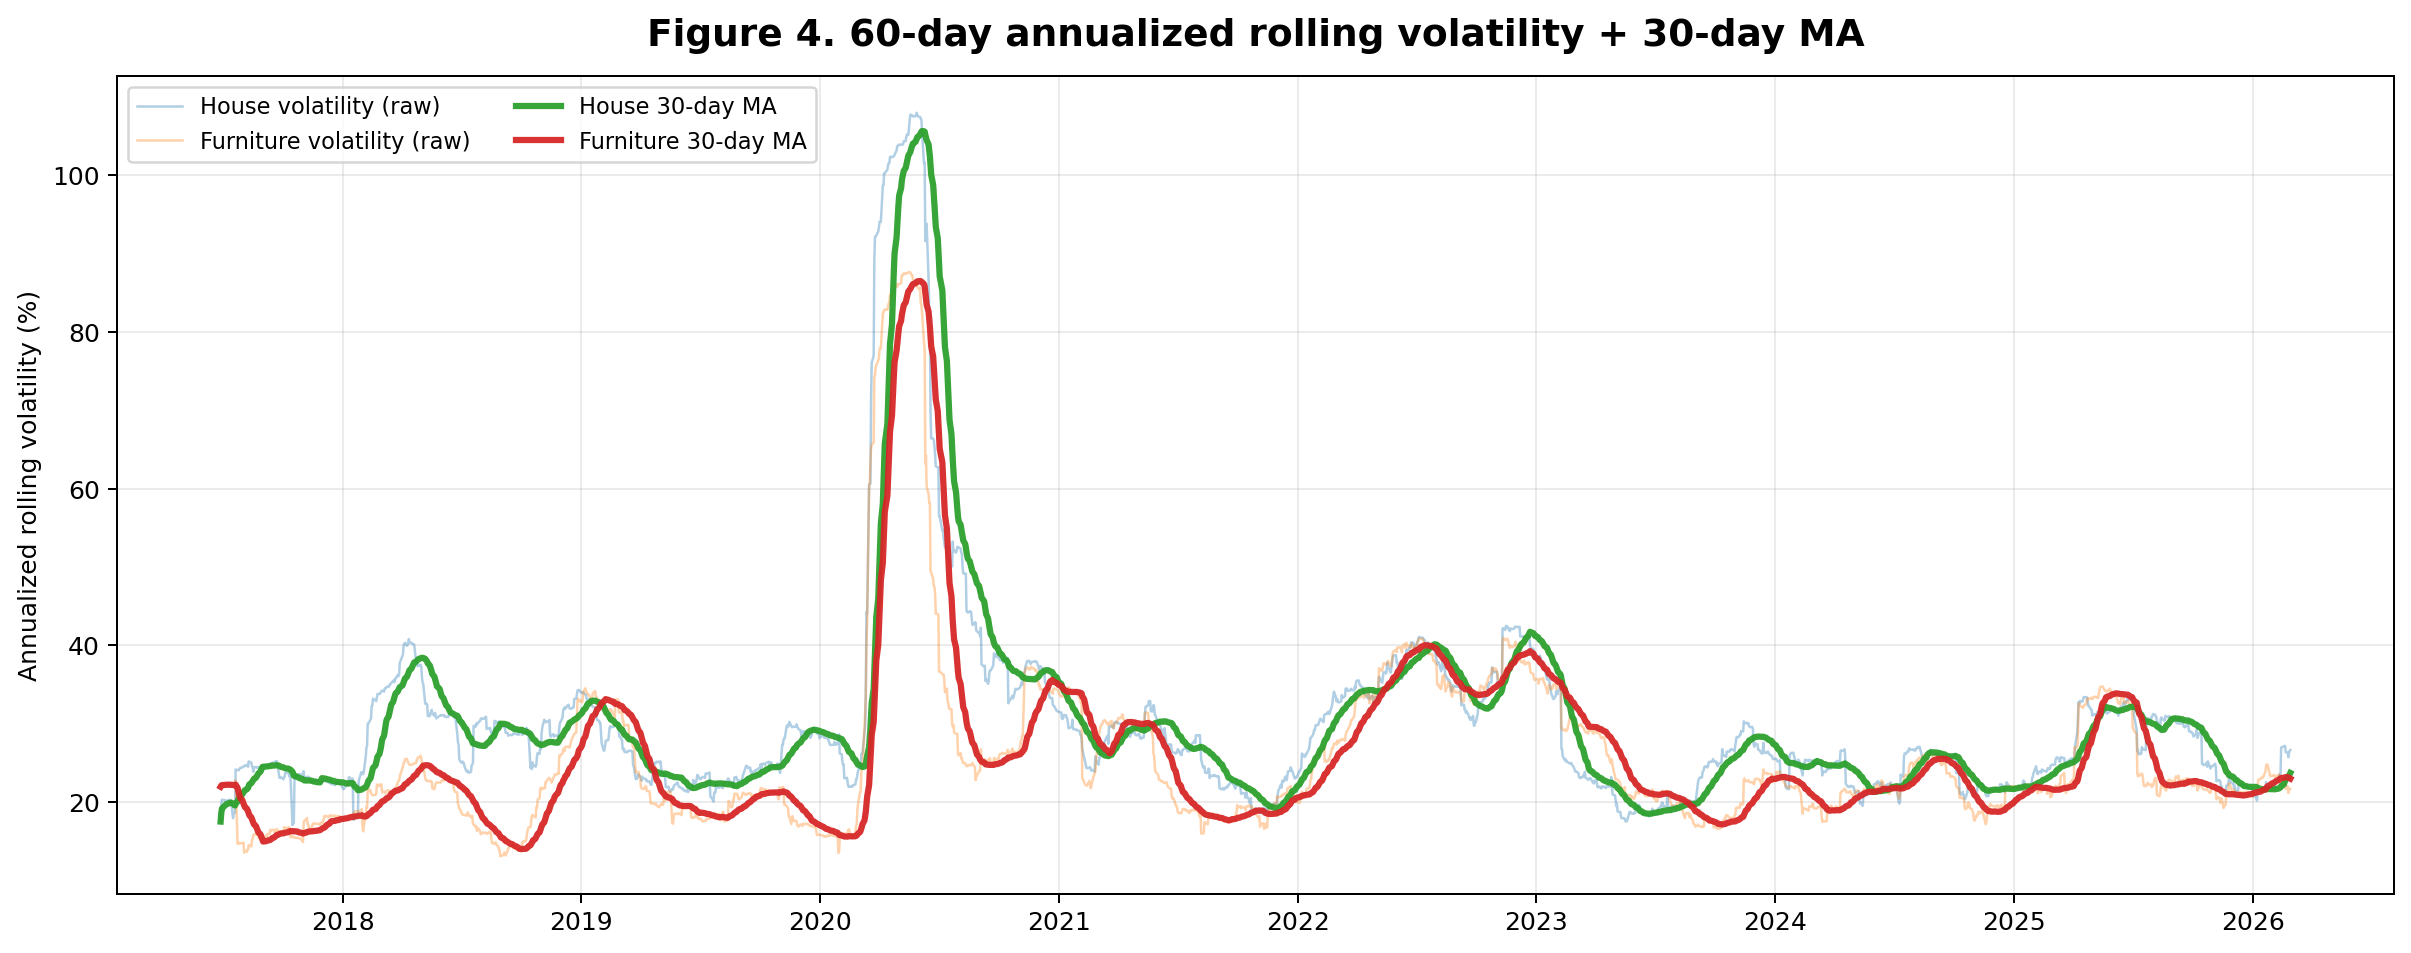

### 图三：House & Furniture 滚动相关性

该图放在 **Lévy Area** 方法之前，用来说明两个板块的相关性并非固定不变，先作为 Lead-Lag 分析的经验动机。

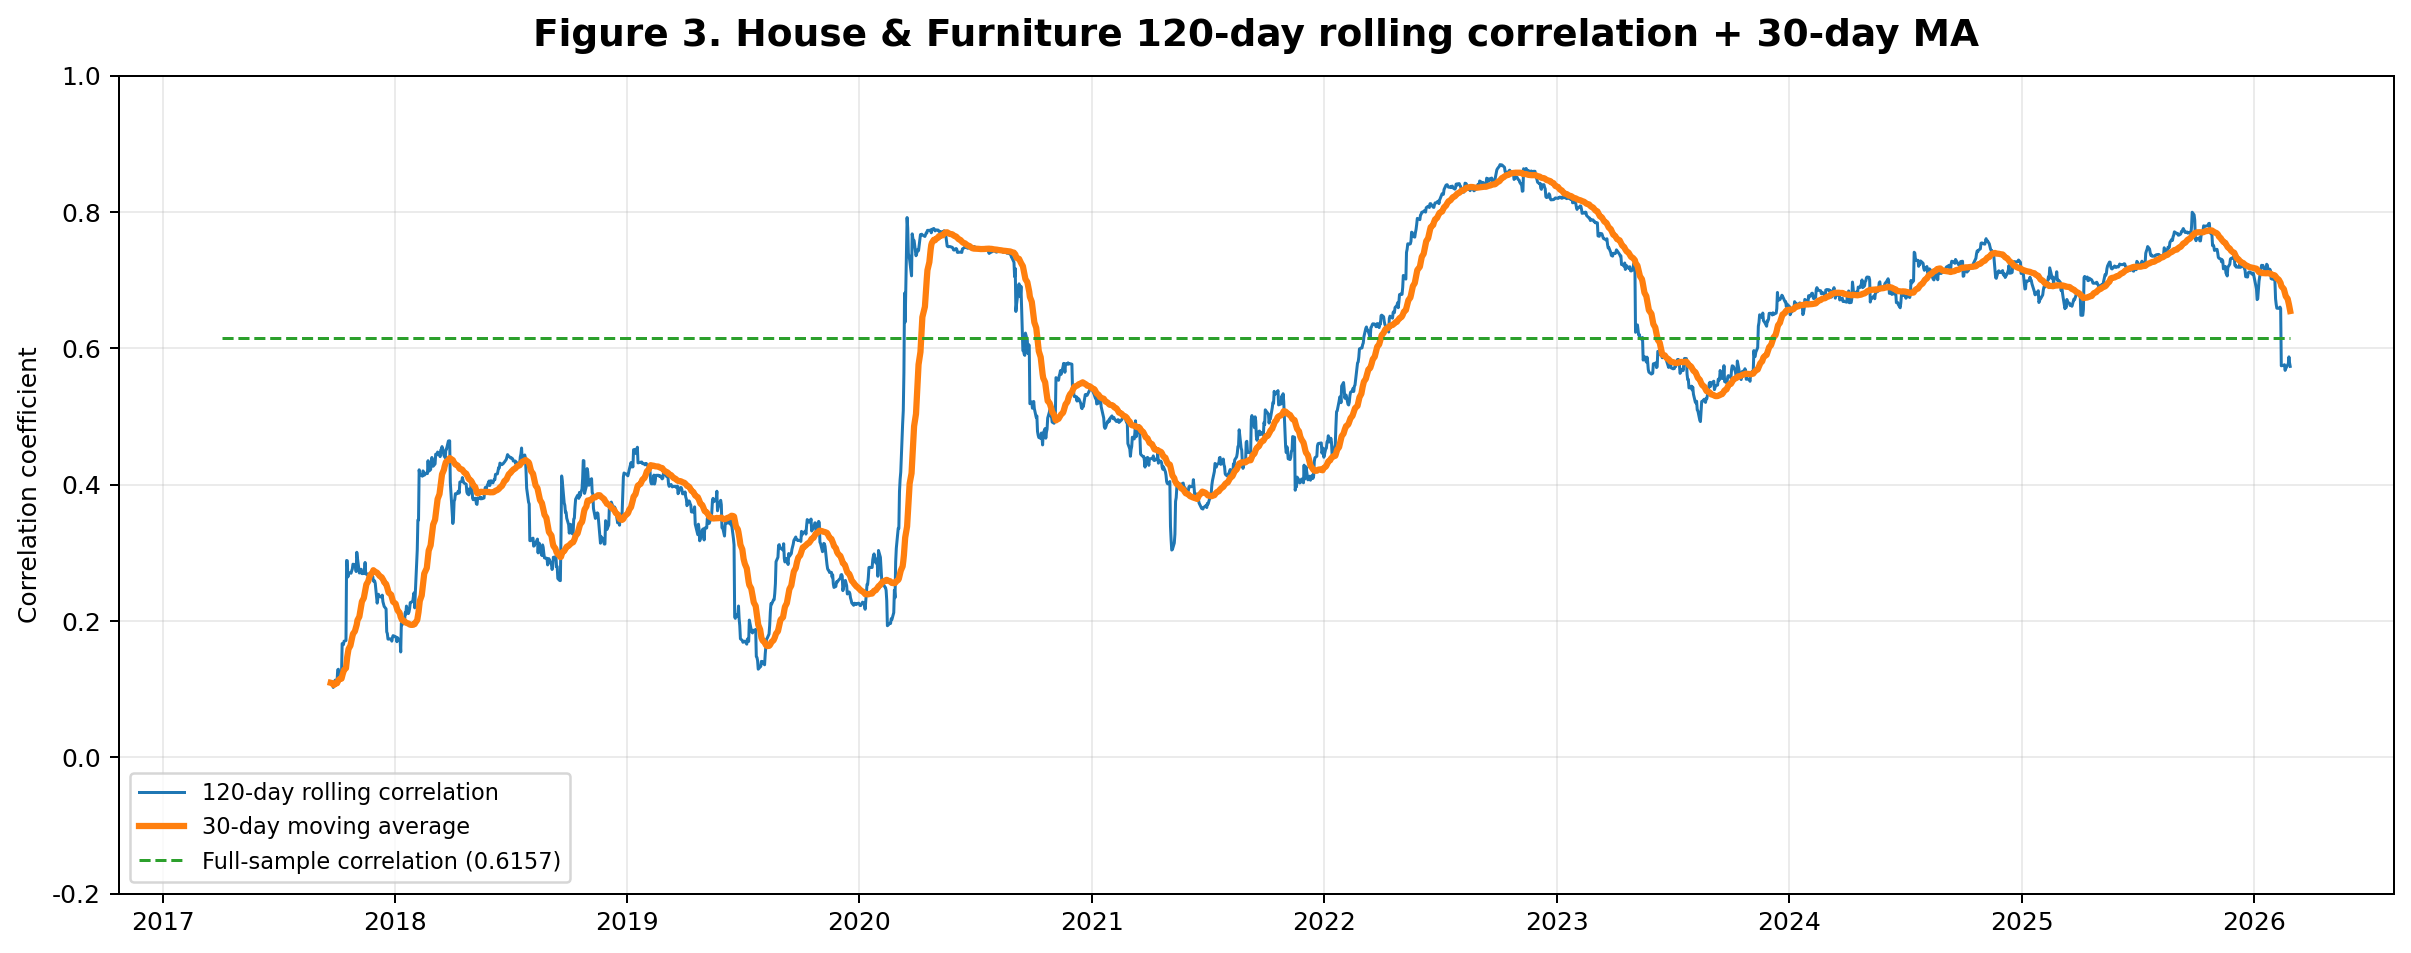

## 3. Methodology Module II: Lévy Area

传统的计量经济学方法在检测领先-滞后关系时，通常只假设时间序列之间存在线性关系。然而，在复杂的金融市场中，资产的波动往往是非线性的。我们引入的 Lévy Area方法能够捕捉由分段连续函数参数化的非线性依赖关系。

对于二维随机过程 $X_t = (X_t^i, X_t^j)$，其在时间区间 $(s, t)$ 上的坐标迭代积分定义为：
$$S(X)_{s,t}^{i,j} = \int_{s<a<t} \int_{s<b<a} dX_b^i dX_a^j$$

由此，我们可以通过计算 Lévy 面积来量化两资产收益率路径之间的领先-滞后关系：
$$A_{i,j}^{Levy} = \frac{1}{2}(S(X)_{s,t}^{i,j} - S(X)_{s,t}^{j,i})$$

**离散逼近与资产排序：**
在离散的日度对数收益率数据中，我们计算各资产累计收益率路径的交错乘积差。最终，我们计算出所有资产对的 Lévy 面积，构建出一个 $N \times N$ 的斜对称矩阵。

通过计算该斜对称矩阵的列均值，我们可以将这 24 支股票从“最可能领先”到“最可能滞后”进行客观排序。在我们的策略中，均值最高的 Top 3 被定义为 **Leaders**（价值驱动者），Bottom 3 被定义为 **Followers**（被动响应者）。

In [6]:
sample_train = returns_df.loc['2019-10-01':'2020-03-31'] 

#计算levy matrix和列均值判断leader/follower
levy_matrix = calculate_levy_area_matrix(sample_train)
col_means = levy_matrix.mean(axis=0).sort_values(ascending=False)
sample_leaders = col_means.head(3).index.tolist()
sample_followers = col_means.tail(3).index.tolist()

print(levy_matrix)

              ETH_history  FND_history  HD_history  LEG_history  LOW_history  \
ETH_history           0.0          NaN         NaN          NaN          NaN   
FND_history           NaN     0.000000   -9.020908   -65.417671   -39.781887   
HD_history            NaN     9.020908    0.000000    -3.935995    -5.821282   
LEG_history           NaN    65.417671    3.935995     0.000000     5.436641   
LOW_history           NaN    39.781887    5.821282    -5.436641     0.000000   
LZB_history           NaN    29.909336   -2.452901    -6.600206    -8.298606   
MHK_history           NaN    28.932540  -13.251559   -14.177853   -20.192560   
MLKN_history          NaN    88.052070   31.109988     8.070513    26.689063   
RH_history            NaN    71.879578   19.325021   -11.594982     2.957713   
SHW_history           NaN    37.717678    5.838484     2.681378     9.054285   
WSM_history           NaN    72.068601   33.270753     6.075899    24.066117   
W_history             NaN    78.407442  

Leaders: ['PSA_history', 'PHM_history', 'FND_history']
Followers: ['WSM_history', 'MLKN_history', 'W_history']



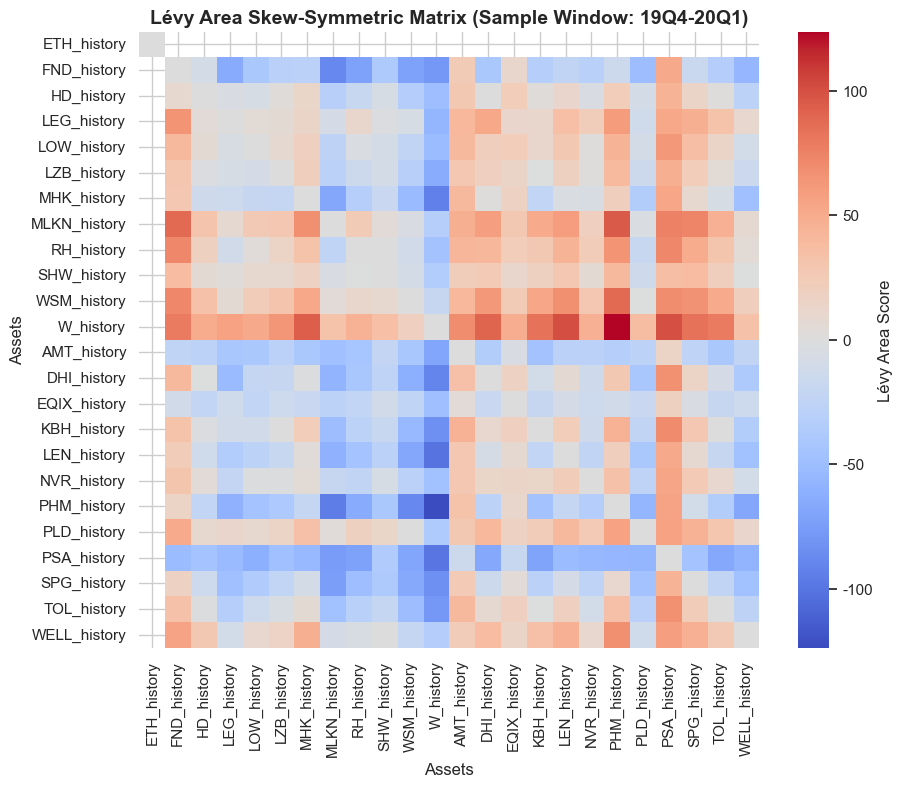

In [7]:
print(f"Leaders: {sample_leaders}")
print(f"Followers: {sample_followers}\n")

#图
plt.figure(figsize=(10, 8))
# 矩阵为斜对称，对角线为0，红蓝对应领先与滞后关系
sns.heatmap(levy_matrix, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Lévy Area Score'})
plt.title('Lévy Area Skew-Symmetric Matrix (Sample Window: 19Q4-20Q1)', fontsize=14, fontweight='bold')
plt.xlabel('Assets')
plt.ylabel('Assets')
plt.show()

## 4. Methodology Module III: State-Conditional Granger Causality

我们认为，市场中信息传导的速度并非恒定，收市场/经济状态的影响，在高波动期和平稳期市场信息的传导速度会有所不同。  
为了找到具体信息传导的速度（滞后期）是多少，我们对 Lévy 选出的 Top 3 Leaders 和 Bottom 3 Followers 进行**条件状态下的Granger Causality Test**。  

对于 Follower 的收益序列 $Y_t$ 和 Leader 的序列 $X_t$，在特定的市场状态下，我们构建如下的向量自回归 (VAR) 模型：
$$Y_t = \alpha + \sum_{k=1}^{L} \beta_k Y_{t-k} + \sum_{k=1}^{L} \gamma_k X_{t-k} + \epsilon_t$$

**Optimization Objective：**
$$\arg\min_{L \in \{1,2,3,5\}} p\text{-value}(\mathcal{H}_0: \gamma_1 = \dots = \gamma_L = 0)$$  

我们为每一个状态分别计算出显著性出现次数最多的平均滞后系数（Lag值），为不同市场状态实现了灵活持仓期的调整。

### 4.1 实现方式说明

lag值的获取方式：

1. 先用 K-Means 在全样本上完成一次性的 Regime 切分，给每个交易日打上 Regime 0 或 Regime 1 的标签。
2. 把属于同一个 Regime 的所有交易日数据汇总在一起，针对 Lévy 选出的 Leaders 和 Followers，在这个汇总后的全部历史样本上运行一次 Granger Causality Test。
3. 这样每个 Regime 只会得到一个全局静态的最优滞后期。

### 图五：双向 Granger 因果检验 P 值

该图放在 **State-Conditional Granger Causality** 之后，作为滞后窗口选择的可视化证据；Lag 3–5 的显著性为后续策略参数提供依据。

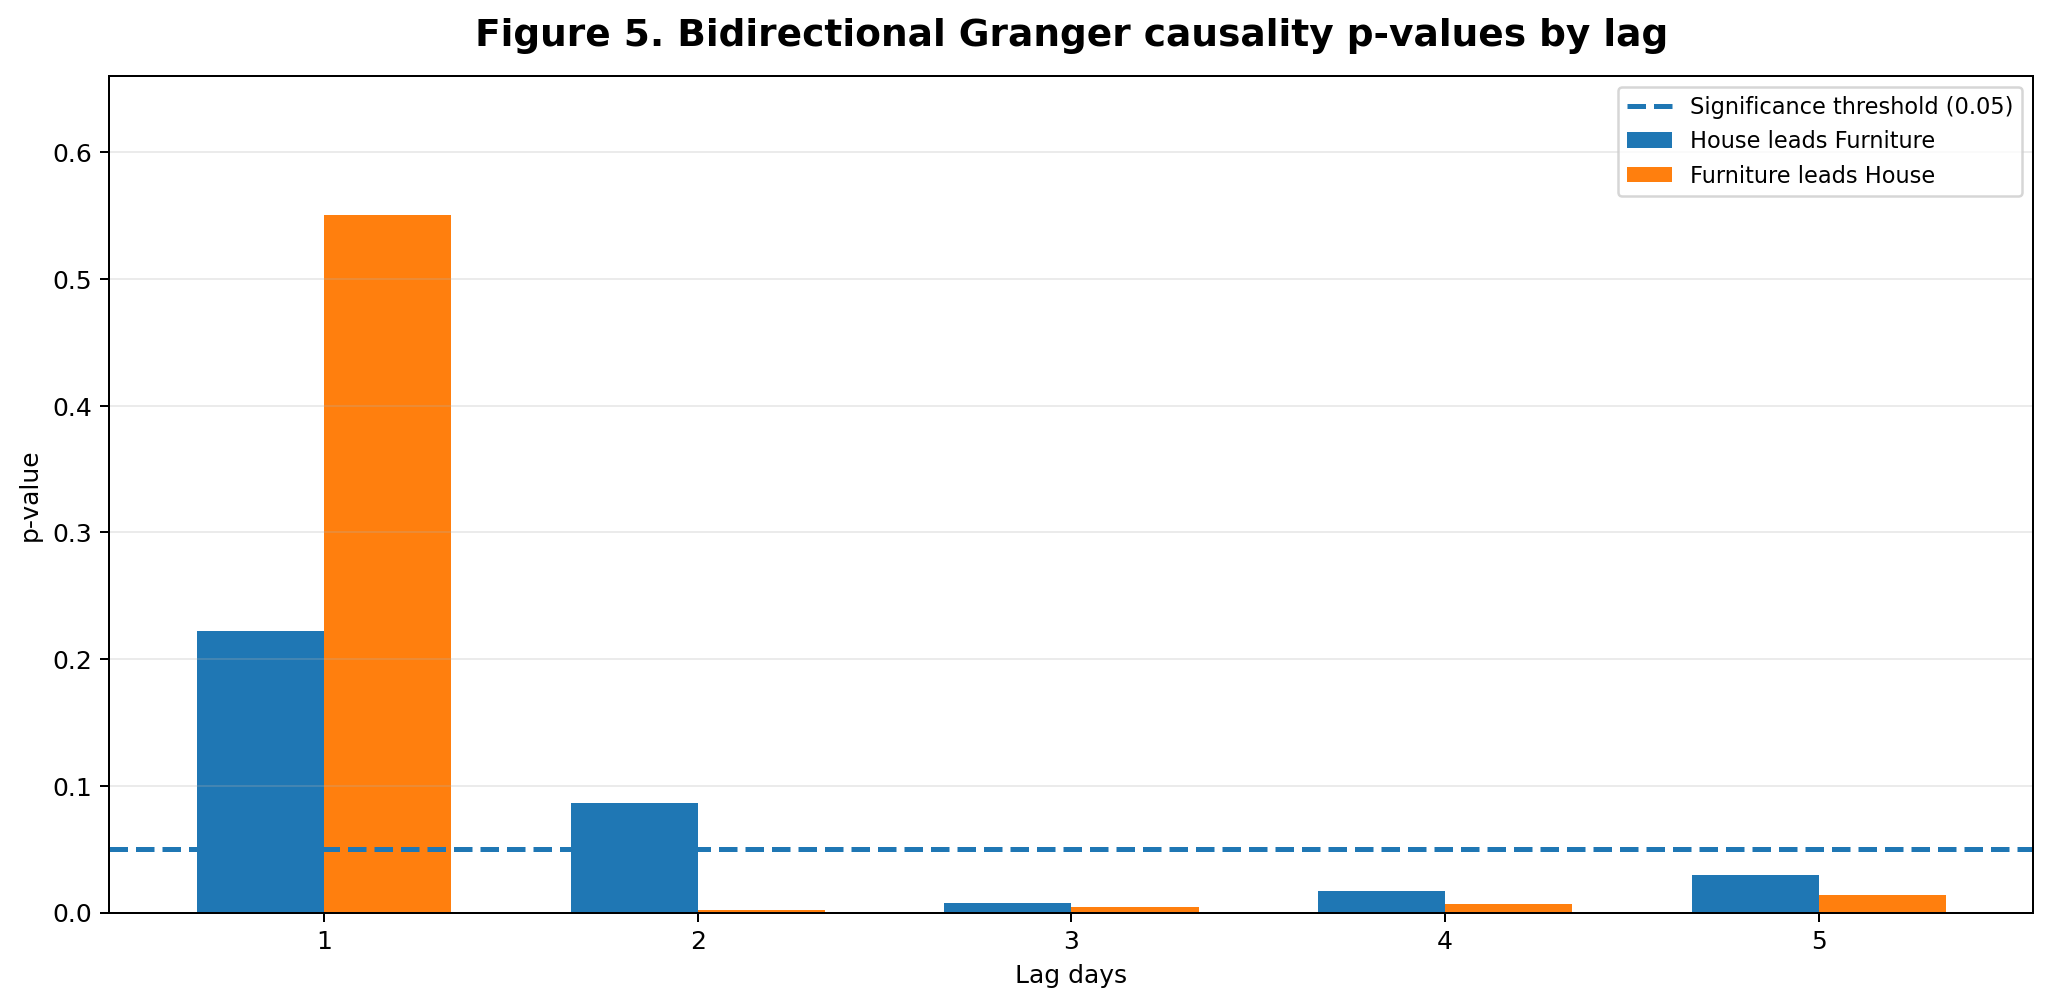

## 5. Strategy Formulation: The Synthesized Engine

### 5.0 模块之间的依赖关系

三个模块不是并列关系，而是有严格的先后顺序：

1. **K-Means** 先回答“现在市场处于什么状态”，把每一个交易日打上 Regime 0 或 Regime 1 的标签，Regime 0 对应市场相对平稳的时期，Regime 1 对应高波动的尾部风险时期，这一步是后面两个模块的前置条件。
2. **Lévy Area** 在已知当前 Regime 的基础上，回答“这个股票池里谁是 Leader，谁是 Follower”，这是一个纯粹基于价格路径的拓扑结构，只负责给出网络中各资产的角色，和具体滞后几天没有关系。
3. **Granger Causality Test** 必须等 Lévy 把 Leader 和 Follower 都选出来之后才能开始算，因为做因果检验需要明确的输入变量，即谁是 X，谁是 Y。在拿到 Leader 和 Follower 之后，再结合 K-Means 给出的 Regime 标签，分别计算出 Regime 0 和 Regime 1 各自对应的最优滞后期 lag_0 和 lag_1。

简单概括：没有 K-Means 就不知道现在该用哪一套参数；没有 Lévy 给出的节点，Granger 根本不知道要拿谁和谁去做因果检验。三者合起来，才能回答最终的交易问题——现在该不该买，应该买什么。
但需要注意的是这并不是实操中的办法，在策略设定前就会得到实际的 lag_0 和 lag_1，只有 Lévy 的计算结果会在实际操作中实时更新。

### 5.1 四个引擎的具体设计

**引擎一：市场状态感知**
做法：放弃引入 VIX 等外部宏观指标，完全依赖股票池内部的横截面波动率和短期动量做无监督聚类。
目的：把市场环境内生地划分成两种状态，作为后两个引擎的前置条件，不需要额外引入主观判断的宏观变量。

**引擎二：核心网络拓扑**
做法：用 Lévy Area 矩阵捕捉资产价格路径之间的非对称超前滞后关系，对得到的斜对称矩阵取列均值并排序，均值最高的 Top 3 资产定义为 Leaders，最低的 Bottom 3 定义为 Followers。
目的：把 11 支股票降维成一条清晰的信息传导链条，锁定信息链顶端和底端的资产。为了应对市场风格的快速切换，这一步在实盘中是逐日滚动更新的，也就是说 Leaders 和 Followers 的具体名单本身会随时间变化。

**引擎三：状态条件定价**
做法：针对引擎二选出的 Leaders 和 Followers，在每个 Regime 各自的历史样本上分别做一次 Granger Causality Test，得到 lag_0 和 lag_1。
目的：建立一张静态的 Regime 到 Lag 的映射表，例如平稳期信息传导慢，需要看过去 3 天的累计收益；高波动期传导快，只需要看过去 1 天。这张表一旦建立完成就不再随每天滚动重算，只有引擎二里的 Leaders/Followers 名单是动态变化的。

**引擎四：动态反转执行**
做法：每日收盘后，先用 K-Means 判断今天属于哪个 Regime，查表得到对应的滞后天数，再看 Leaders 在过去这几天的累计收益率。
规则：
- Leaders 累计上涨，预测 Followers 即将补跌，于是规避风险，满仓买入大盘基准，赚取 Beta。
- Leaders 累计下跌，预测 Followers 即将反弹，于是主动出击，满仓买入 Followers，赚取 Alpha。

### 5.2 每日决策流程

```
每日收盘时：
  Step 1. [K-Means]  输入今日横截面波动率 + 动量 → 判断当前 Regime (0 或 1)
  Step 2. [查表]      根据 Regime 从静态映射表中取出对应滞后期 lag_0 或 lag_1
  Step 3. [Lévy]      用最新数据滚动更新 Leaders / Followers 名单
  Step 4. [回看信号]  取 Leaders 过去 lag 天的累计收益
         ├── 累计上涨 → 满仓买入等权大盘，规避板块下行风险
         └── 累计下跌 → 满仓买入 Followers，捕获反弹 Alpha
```

### 5.3 策略特点

- **Long-Only 设计**：完全避免做空成本和逼空风险。
- **永不空仓**：上涨信号持大盘，下跌信号持 Followers，账户始终有收益来源，不存在空仓踏空的情况。
- **参数分层更新**：Leaders/Followers 名单逐日滚动更新，以适应市场风格切换；Regime 到 Lag 的映射表则是基于全样本一次性计算得到的静态参数，避免频繁重算带来的噪音和参数不稳定。

最终样本外回测绩效:
📈 Cumulative_Return: 292.43%
📈 Annualized_Return: 17.14%
📊 Sharpe_Ratio: 0.6145


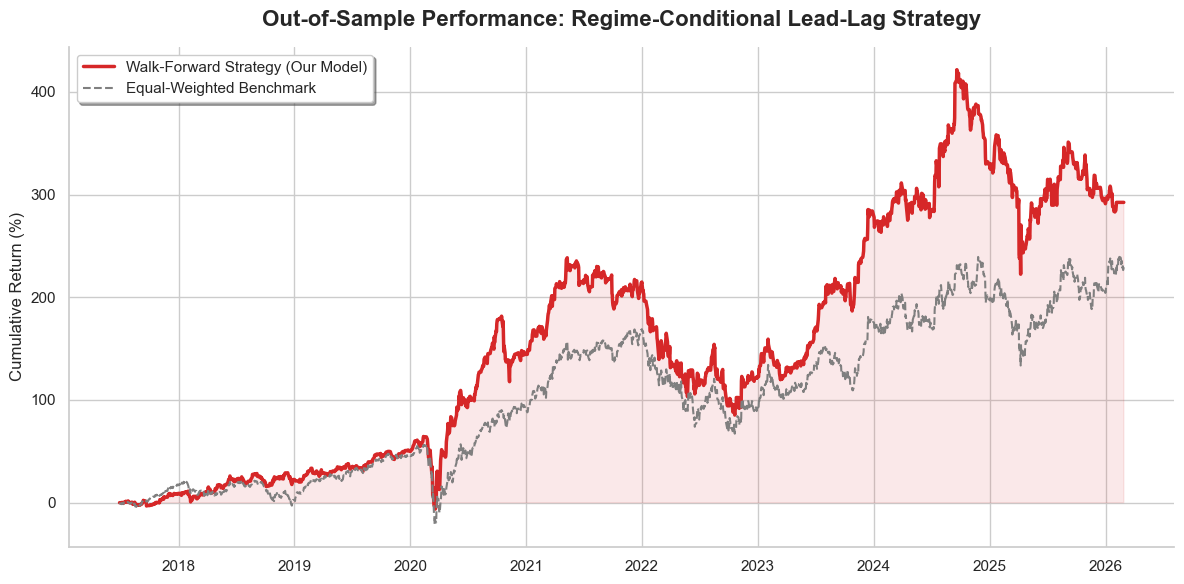

In [8]:
#回测
strategy_results = walk_forward_synthesized_strategy(returns_df, train_days=60, test_days=20, lags=[1, 2, 3, 5])

# 计算核心绩效指标
metrics = evaluate_backtest_performance(strategy_results)
print("最终样本外回测绩效:")
for k, v in metrics.items():
    if 'Return' in k:
        print(f"📈 {k}: {v*100:.2f}%")
    else:
        print(f"📊 {k}: {v:.4f}")

# 绘制累积净值对比图
strat_daily = strategy_results['Strategy_Return']
bench_daily = returns_df.mean(axis=1).loc[strat_daily.index]

cum_strat = (1 + strat_daily).cumprod() - 1
cum_bench = (1 + bench_daily).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_strat.index, cum_strat.values * 100, label='Walk-Forward Strategy (Our Model)', linewidth=2.5, color='#d62728')
ax.plot(cum_bench.index, cum_bench.values * 100, label='Equal-Weighted Benchmark', linewidth=1.5, color='#7f7f7f', linestyle='--')

ax.fill_between(cum_strat.index, cum_strat.values * 100, 0, where=(cum_strat.values >= 0), color='#d62728', alpha=0.1)
ax.fill_between(cum_strat.index, cum_strat.values * 100, 0, where=(cum_strat.values < 0), color='#1f77b4', alpha=0.1)

ax.set_title('Out-of-Sample Performance: Regime-Conditional Lead-Lag Strategy', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 5.1 Ablation Study: Unconditional Baseline

为了证明 K-Means 状态条件方法的有效性，我们设置一个 **Unconditional Baseline**：  
不做任何聚类，不识别市场状态，直接在全局数据上固定使用最常见的滞后期（lag=1）进行相同的 Leaders→Followers 交易策略。  

若我们原策略的 **Sharpe Ratio** 和累计收益显著高于此 Baseline，则证明 K-Means 聚类引入的状态信息确实有增量价值；否则说明复杂模型未能带来真正的提升。


====== Ablation Study: K-Means Model vs. Unconditional Baseline ======
  K-Means Strategy   | Sharpe: 0.7041  | Cum Return: 292.43%
  Unconditional(lag=1)| Sharpe: 0.3854  | Cum Return: 87.87%
  Sharpe Improvement from K-Means: +0.3187


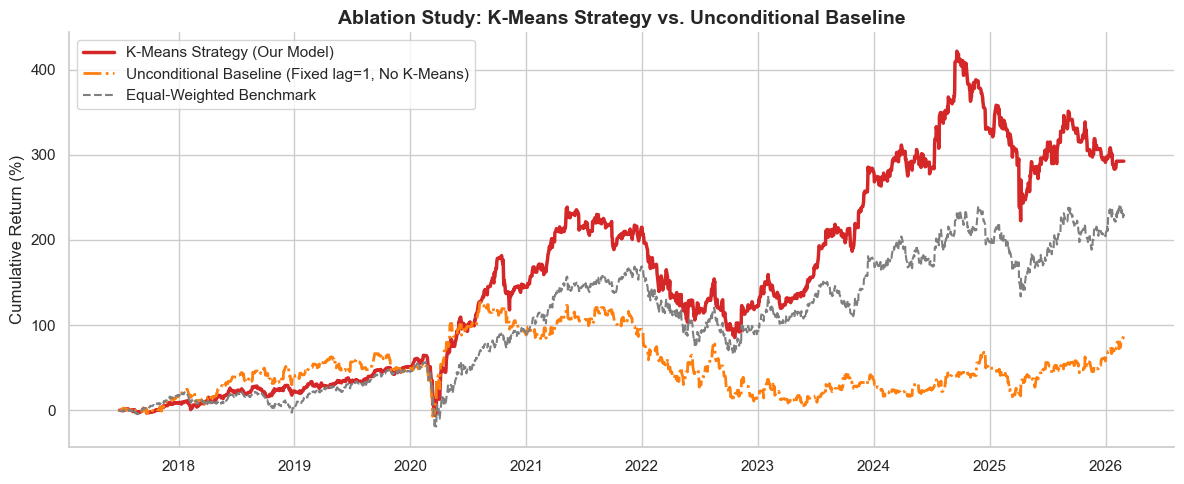

In [9]:
import numpy as np
import pandas as pd

# === Ablation Study: Unconditional Baseline（无条件基准对照组）===
# 不使用 K-Means，固定 lag=1，直接跑相同的 leader/follower 逻辑

strat_index = strategy_results.index
spy_proxy = aligned_benchmark.reindex(strat_index)

unconditional_returns = []
for i, date in enumerate(strat_index):
    try:
        loc_idx = returns_df.index.get_loc(date)
        if loc_idx < 1:
            unconditional_returns.append(0.0)
            continue
        prev_date = returns_df.index[loc_idx - 1]
        # 用样本期 followers（sample_followers 为 Section 3 计算的全局 followers）
        leader_ret = returns_df.loc[prev_date, sample_leaders].mean()
        if leader_ret < 0:
            # Leaders 前一天下跌 → 做多 Followers
            ret = returns_df.loc[date, sample_followers].mean()
        else:
            # Leaders 前一天上涨 → 持大盘
            ret = spy_proxy.loc[date] if date in spy_proxy.index and not pd.isna(spy_proxy.loc[date]) else returns_df.loc[date].mean()
        unconditional_returns.append(ret)
    except Exception:
        unconditional_returns.append(0.0)

uncond_series = pd.Series(unconditional_returns, index=strat_index)

# Sharpe Ratio helper
def sharpe(ret_series, rf=0.0):
    excess = ret_series - rf / 252
    return (excess.mean() / excess.std() * np.sqrt(252)) if excess.std() > 1e-9 else 0.0

strat_daily = strategy_results['Strategy_Return']
bench_daily = returns_df.mean(axis=1).loc[strat_index]
cum_strat = (1 + strat_daily).cumprod() - 1
cum_bench = (1 + bench_daily).cumprod() - 1
cum_uncond = (1 + uncond_series).cumprod() - 1

main_sharpe  = sharpe(strat_daily)
uncond_sharpe = sharpe(uncond_series)

print("====== Ablation Study: K-Means Model vs. Unconditional Baseline ======")
print(f"  K-Means Strategy   | Sharpe: {main_sharpe:.4f}  | Cum Return: {cum_strat.iloc[-1]*100:.2f}%")
print(f"  Unconditional(lag=1)| Sharpe: {uncond_sharpe:.4f}  | Cum Return: {cum_uncond.iloc[-1]*100:.2f}%")
print(f"  Sharpe Improvement from K-Means: {main_sharpe - uncond_sharpe:+.4f}")

# 对比图
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_strat.index, cum_strat.values * 100,
        label='K-Means Strategy (Our Model)', linewidth=2.5, color='#d62728')
ax.plot(cum_uncond.index, cum_uncond.values * 100,
        label='Unconditional Baseline (Fixed lag=1, No K-Means)', linewidth=2, color='#ff7f0e', linestyle='-.')
ax.plot(cum_bench.index, cum_bench.values * 100,
        label='Equal-Weighted Benchmark', linewidth=1.5, color='#7f7f7f', linestyle='--')
ax.set_title('Ablation Study: K-Means Strategy vs. Unconditional Baseline', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()


## 6.Results Interpretation
对于聚类结果、具体滞后周期的计算和市场状态切分的结果展示如下：

================= 聚类结果 =================
状态 0 的平均横截面波动率: 0.0165
状态 1 的平均横截面波动率: 0.0676


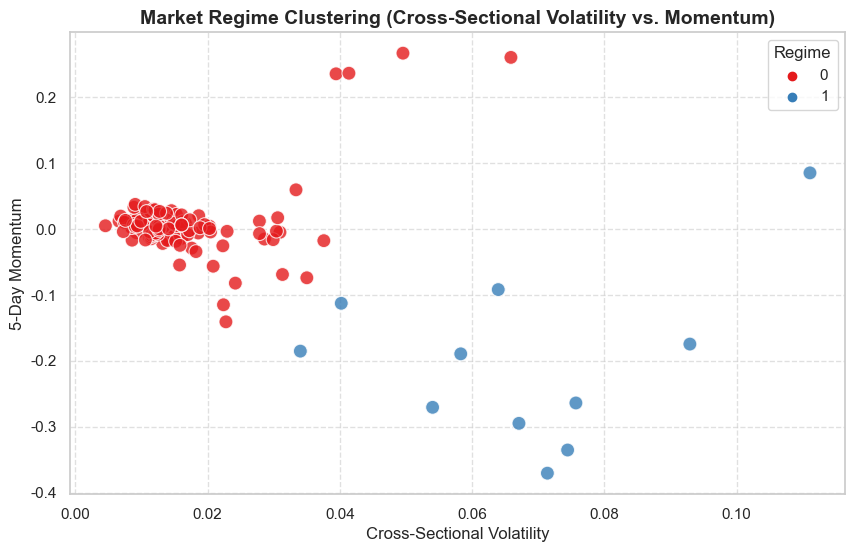


================= 滞后周期 =================
--> 在平稳环境下，最优信息传导滞后天数为: 3 天
--> 在波动环境下，最优信息传导滞后天数为: 1 天


In [11]:
print("================= 聚类结果 =================")
sample_features = prepare_clustering_features(sample_train)
sample_regimes, sample_kmeans, sample_scaler = train_regime_clustering(sample_features)

vol_0 = sample_features.loc[sample_regimes['Regime'] == 0, 'Cross_Vol'].mean()
vol_1 = sample_features.loc[sample_regimes['Regime'] == 1, 'Cross_Vol'].mean()
print(f"状态 0 的平均横截面波动率: {vol_0:.4f}")
print(f"状态 1 的平均横截面波动率: {vol_1:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_features, x='Cross_Vol', y='Momentum_5D', 
                hue=sample_regimes['Regime'], palette='Set1', s=100, alpha=0.8)
plt.title('Market Regime Clustering (Cross-Sectional Volatility vs. Momentum)', fontsize=14, fontweight='bold')
plt.xlabel('Cross-Sectional Volatility', fontsize=12)
plt.ylabel('5-Day Momentum', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n================= 滞后周期 =================")
# 4. 根据聚类结果，将数据严格划分为两个状态集
data_regime_0 = sample_train.loc[sample_regimes[sample_regimes['Regime'] == 0].index]
data_regime_1 = sample_train.loc[sample_regimes[sample_regimes['Regime'] == 1].index]

# 5. 分别计算不同状态下的最优信息传导天数
lag_0 = get_3x3_optimal_lag(data_regime_0, sample_leaders, sample_followers, lags=[1, 2, 3, 5])
lag_1 = get_3x3_optimal_lag(data_regime_1, sample_leaders, sample_followers, lags=[1, 2, 3, 5])

print(f"--> 在平稳环境下，最优信息传导滞后天数为: {lag_0} 天")
print(f"--> 在波动环境下，最优信息传导滞后天数为: {lag_1} 天")

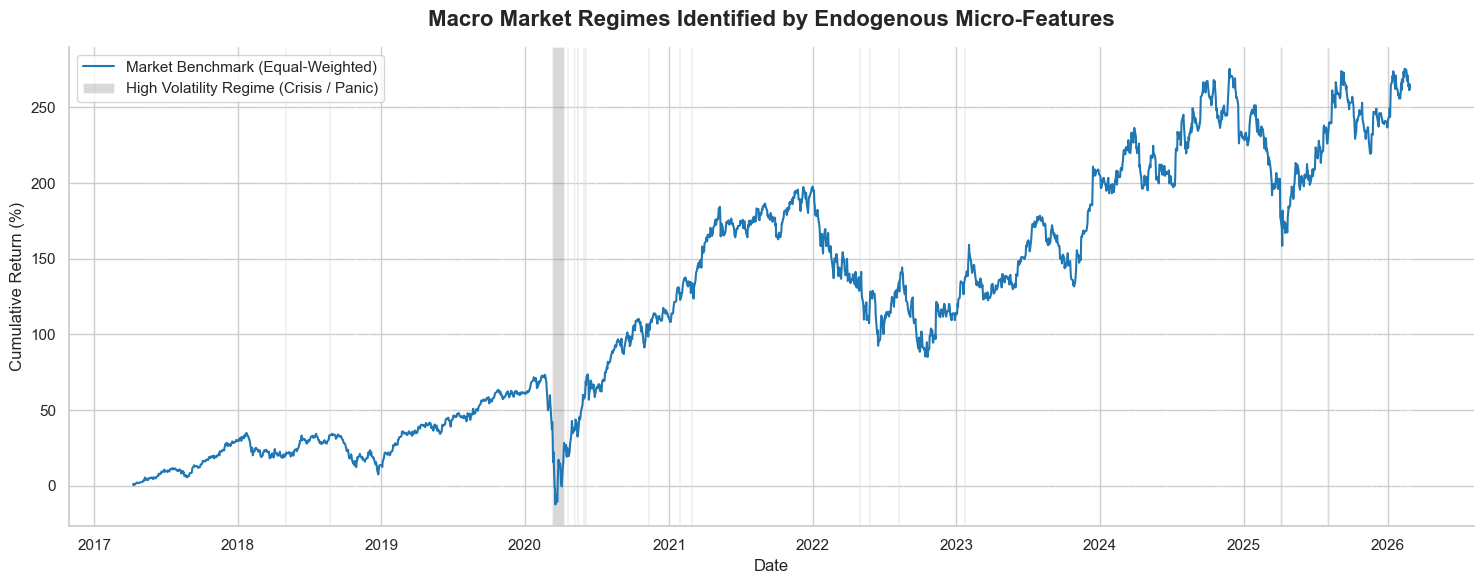

In [12]:
plot_regime_shading_chart(returns_df)

## 7.Forcasting
为了检验此策略在实际市场运用的效果，我们提取了新两个月的股票数据作为验证集。验证思路为：利用当天收盘价计算隔天的交易策略，并按此交易。最终比较收益情况。

正在从历史数据的最后 60 天提取最新实盘拓扑结构...
实盘参数：
Leaders: ['WELL_history', 'AMT_history', 'PSA_history']
Followers: ['RH_history', 'LEG_history', 'W_history']
新数据维度: (43, 24)

🚀 开启 动态流式预测 (Live OOS Simulation with Rolling Topology)...
策略累计收益: -3.419%
基准累计收益: -7.551%
捕获超额收益 (Alpha): +4.132%


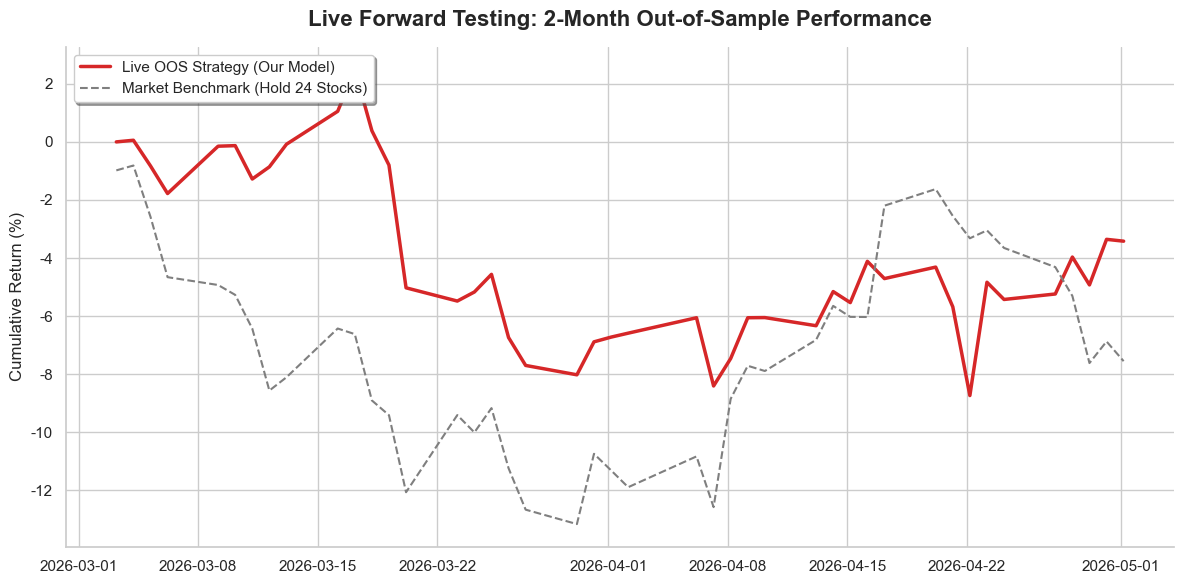

In [17]:
#之前计算的lead和lag
live_leaders, live_followers, live_kmeans, live_scaler = extract_latest_model_parameters(returns_df)

new_returns_df = load_prediction_data("prediction")

# 你的新调用方式：
oos_performance = run_live_prediction_simulation_dynamic(
    historical_df=returns_df, 
    new_returns_df=new_returns_df, 
    trained_kmeans=live_kmeans, 
    trained_scaler=live_scaler, 
    lag_0=lag_0,                
    lag_1=lag_1                 
)

#图
cum_strategy = (1 + oos_performance['OOS_Strategy_Return']).cumprod() - 1
cum_benchmark = (1 + oos_performance['Market_Benchmark']).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_strategy.index, cum_strategy.values * 100, label='Live OOS Strategy (Our Model)', linewidth=2.5, color='#d62728')
ax.plot(cum_benchmark.index, cum_benchmark.values * 100, label='Market Benchmark (Hold 24 Stocks)', linewidth=1.5, color='#7f7f7f', linestyle='--')

ax.set_title('Live Forward Testing: 2-Month Out-of-Sample Performance', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)

print(f"策略累计收益: {cum_strategy.iloc[-1]*100:.3f}%")
print(f"基准累计收益: {cum_benchmark.iloc[-1]*100:.3f}%")
alpha = cum_strategy.iloc[-1]*100 - cum_benchmark.iloc[-1]*100
print(f"捕获超额收益 (Alpha): +{alpha:.3f}%")

sns.despine()
plt.tight_layout()
plt.show()